# 🚀 LightGBM — Light Gradient Boosting Machine

> **Part of:** Basics → Ensemble_Methods → Boosting

---

## 📌 What is LightGBM?

**LightGBM** is a gradient boosting framework developed by **Microsoft** in 2017.
It is designed to be faster and more memory-efficient than XGBoost.


In [1]:
# !pip install lightgbm scikit-learn matplotlib seaborn pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier, plot_importance

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

import lightgbm
print('✅ Libraries imported successfully!')
print(f'LightGBM version: {lightgbm.__version__}')

✅ Libraries imported successfully!
LightGBM version: 4.6.0


## 📊 Step 2 — Load & Explore Dataset

We use the same **Breast Cancer dataset** for direct comparison with Random Forest and XGBoost:
- 569 samples, 30 features
- Binary classification: Malignant (0) vs Benign (1)

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Dataset Shape  :', X.shape)
print('Classes        :', data.target_names)
print('\nClass Distribution:')
print(y.value_counts())
print('\nFirst 5 rows:')
X.head()

Dataset Shape  : (569, 30)
Classes        : ['malignant' 'benign']

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## ✂️ Step 3 — Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 455
Testing  samples : 114


---
## 🤖 Step 4 — Train Basic LightGBM Model

In [5]:
lgbm = LGBMClassifier(
    n_estimators=100,      # number of boosting rounds
    learning_rate=0.1,     # step size shrinkage
    max_depth=-1,          # -1 means no limit (leaf-wise controls depth)
    num_leaves=31,         # max leaves per tree (key LightGBM parameter)
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
auc    = roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])

print(f'✅ LightGBM Accuracy : {acc:.4f}')
print(f'✅ AUC-ROC Score     : {auc:.4f}')
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=data.target_names))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000640 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

---
## 📉 Step 5 — Confusion Matrix

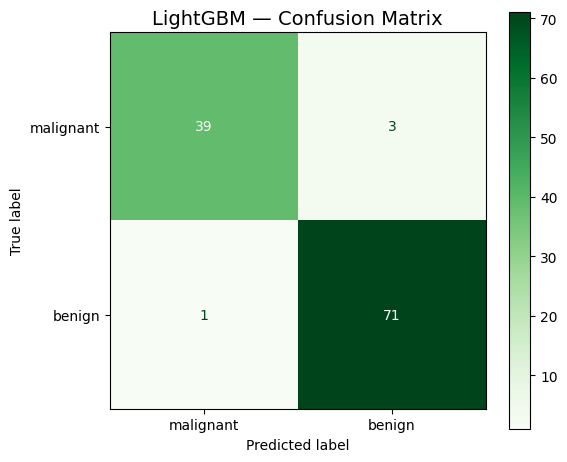

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=data.target_names,
    cmap='Greens', ax=ax
)
plt.title('LightGBM — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

---
## 📈 Step 6 — ROC Curve

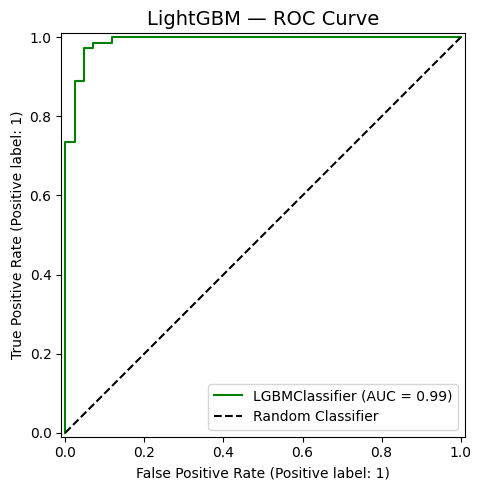

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(lgbm, X_test, y_test, ax=ax, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('LightGBM — ROC Curve', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

---
## 📊 Step 7 — Feature Importance

In [ ]:
importances = pd.Series(lgbm.feature_importances_, index=data.feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, palette='Greens_r')
plt.title('Top 10 Feature Importances — LightGBM', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 🍃 Step 8 — Effect of num_leaves

> `num_leaves` is the most important LightGBM parameter — it controls model complexity

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of

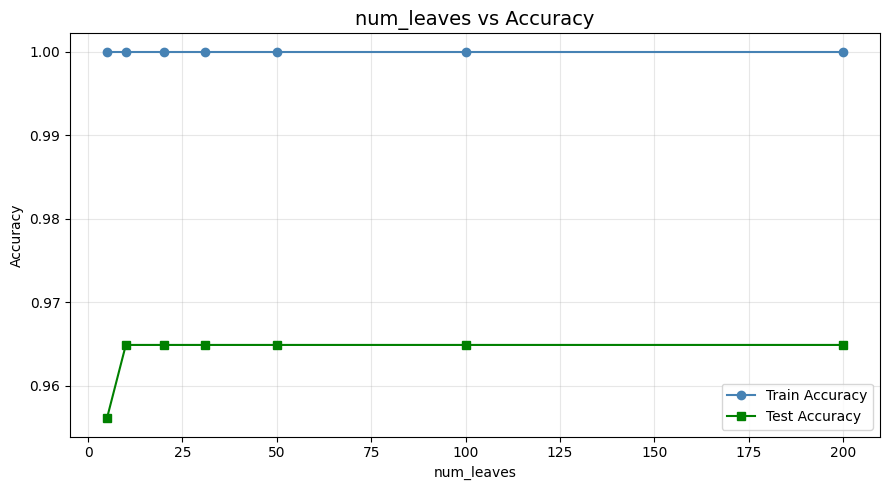

In [8]:
leaf_values  = [5, 10, 20, 31, 50, 100, 200]
train_scores = []
test_scores  = []

for nl in leaf_values:
    model = LGBMClassifier(n_estimators=100, num_leaves=nl, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(leaf_values, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(leaf_values, test_scores,  's-', label='Test Accuracy',  color='green')
plt.xlabel('num_leaves')
plt.ylabel('Accuracy')
plt.title('num_leaves vs Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🛑 Step 9 — Early Stopping

In [9]:
from lightgbm import early_stopping, log_evaluation

lgbm_es = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

lgbm_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[early_stopping(stopping_rounds=20), log_evaluation(period=50)]
)

print(f'\nBest iteration : {lgbm_es.best_iteration_}')
print(f'Accuracy       : {accuracy_score(y_test, lgbm_es.predict(X_test)):.4f}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

---
## 🔁 Step 10 — Cross Validation

In [10]:
lgbm_cv = LGBMClassifier(n_estimators=100, learning_rate=0.1,
                          num_leaves=31, random_state=42)

cv_scores = cross_val_score(lgbm_cv, X, y, cv=5, scoring='accuracy')

print('Cross-Validation Scores (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean Accuracy : {cv_scores.mean():.4f}')
print(f'Std Dev       : {cv_scores.std():.4f}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

---
## ⏱️ Step 11 — Speed Comparison: LightGBM vs XGBoost

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

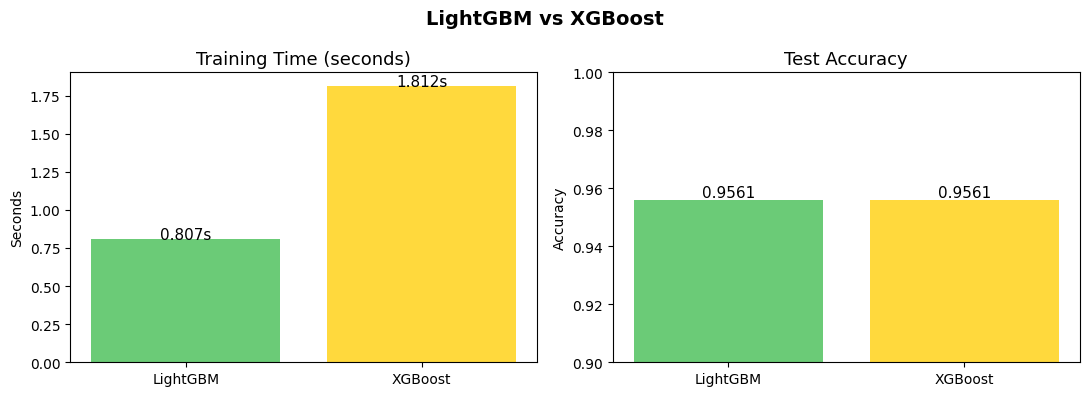

In [11]:
import time
from xgboost import XGBClassifier

# LightGBM timing
start = time.time()
lgbm_t = LGBMClassifier(n_estimators=200, random_state=42)
lgbm_t.fit(X_train, y_train)
lgbm_time = time.time() - start
lgbm_acc  = lgbm_t.score(X_test, y_test)

# XGBoost timing
start = time.time()
xgb_t = XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42)
xgb_t.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_acc  = xgb_t.score(X_test, y_test)

# Results
results = pd.DataFrame({
    'Model'        : ['LightGBM', 'XGBoost'],
    'Training Time': [lgbm_time, xgb_time],
    'Accuracy'     : [lgbm_acc,  xgb_acc]
})

print(results.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['LightGBM', 'XGBoost'], [lgbm_time, xgb_time],
            color=['#6bcb77', '#ffd93d'])
axes[0].set_title('Training Time (seconds)', fontsize=13)
axes[0].set_ylabel('Seconds')
for i, v in enumerate([lgbm_time, xgb_time]):
    axes[0].text(i, v + 0.001, f'{v:.3f}s', ha='center', fontsize=11)

axes[1].bar(['LightGBM', 'XGBoost'], [lgbm_acc, xgb_acc],
            color=['#6bcb77', '#ffd93d'])
axes[1].set_title('Test Accuracy', fontsize=13)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.9, 1.0)
for i, v in enumerate([lgbm_acc, xgb_acc]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)

plt.suptitle('LightGBM vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📝 Key Hyperparameters

| Parameter | Default | What it Controls | Tuning Tip |
|---|---|---|---|
| `n_estimators` | 100 | Number of boosting rounds | Higher = better (use early stopping) |
| `learning_rate` | 0.1 | Step size shrinkage | Lower + more trees = better |
| `num_leaves` | 31 | Max leaves per tree (**most important**) | Keep < 2^max_depth |
| `max_depth` | -1 | Max tree depth | -1 = unlimited (num_leaves controls it) |
| `min_child_samples` | 20 | Min samples per leaf | Higher = more regularization |
| `subsample` | 1.0 | Row sampling per tree | 0.8 reduces overfitting |
| `colsample_bytree` | 1.0 | Feature sampling per tree | 0.8 more diverse trees |
| `reg_alpha` | 0 | L1 regularization | Feature selection |
| `reg_lambda` | 0 | L2 regularization | Smoothing weights |

---

## 🚀 When to Use LightGBM

✅ **Large datasets** (millions of rows) — much faster than XGBoost  
✅ **Limited memory** — more efficient than XGBoost  
✅ **Categorical features** — handles natively without encoding  
✅ **Kaggle / competitions** — top choice alongside XGBoost  
✅ When training speed matters  

❌ Very small datasets — may overfit (use `min_child_samples`)  
❌ Image / Audio / Text data (use Deep Learning)  

---

## 🧠 Rule of Thumb

```
Small dataset   → Random Forest or XGBoost
Large dataset   → LightGBM (faster + memory efficient)
Best accuracy   → Try both XGBoost and LightGBM, compare
```